# 🛒 CODTECH IT Solutions — Data Analytics Internship
## Task 1: Big Data Analysis
### Project: Indian E-Commerce Sales Big Data Analysis using Dask


| Field | Details |
|-------|---------|
| **Name** | Ritesh Chandra |
| **Company** | CODTECH IT Solutions Pvt. Ltd. |
| **Intern ID** | CITS419 |
| **Domain** | Data Analytics |
| **Duration** | 4 Weeks |
| **Mentor** | Neela Santhosh Kumar |

---

### 🎯 Objective
Perform scalable **Big Data Analysis** on a large Indian e-commerce dataset (50,000 orders × 48 columns) using **Dask** for parallel processing. Derive meaningful business insights on sales, customers, products, regions, and platform performance.

### 📌 Analysis Sections
1. Environment Setup & Data Loading with Dask
2. Dataset Overview & Quality Check
3. KPI Dashboard
4. Sales & Revenue Analysis
5. Category & Product Analysis
6. Customer & Demographic Analysis
7. Platform & Device Analysis
8. Regional Analysis
9. Returns & Refund Analysis
10. Key Insights Summary

---
## Section 1 — Environment Setup

In [4]:
# Install required libraries (run once)
# !pip install dask pandas matplotlib seaborn pyarrow

In [5]:
import dask.dataframe as dd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

print('=' * 55)
print('  CODTECH TASK 1 — Indian E-Commerce Big Data')
print('=' * 55)


  CODTECH TASK 1 — Indian E-Commerce Big Data


---
## Section 2 — Load Data with Dask

In [6]:
# Load with Dask — lazy parallel read
ddf = dd.read_csv('ecommerce_big_data.csv', dtype=str)

print(f'Dask Partitions : {ddf.npartitions}')
print(f'Total Columns   : {len(ddf.columns)}')
print(f'Columns         : {list(ddf.columns)}')

Dask Partitions : 1
Total Columns   : 48
Columns         : ['order_id', 'order_date', 'order_month', 'order_quarter', 'order_year', 'customer_id', 'customer_name_initial', 'customer_age_group', 'customer_gender', 'customer_occupation', 'customer_segment', 'customer_since_year', 'city', 'state', 'pincode', 'tier', 'platform', 'device_type', 'traffic_source', 'category', 'subcategory', 'brand', 'product_id', 'product_name_code', 'unit_price_inr', 'quantity', 'discount_percent', 'discount_amount_inr', 'selling_price_inr', 'gst_percent', 'gst_amount_inr', 'total_amount_inr', 'payment_method', 'emi_months', 'wallet_name', 'shipping_method', 'shipping_cost_inr', 'delivery_days', 'order_status', 'return_flag', 'return_reason', 'refund_amount_inr', 'warehouse', 'seller_id', 'seller_rating', 'product_rating', 'review_count', 'wishlist_flag']


In [7]:
# Convert to pandas for full analysis
pdf = ddf.compute()

# Type conversions
num_cols = ['unit_price_inr','quantity','discount_percent','discount_amount_inr',
            'selling_price_inr','gst_amount_inr','total_amount_inr',
            'shipping_cost_inr','delivery_days','refund_amount_inr',
            'seller_rating','product_rating','review_count',
            'return_flag','wishlist_flag','emi_months','gst_percent']
for col in num_cols:
    pdf[col] = pd.to_numeric(pdf[col], errors='coerce')
pdf['order_date'] = pd.to_datetime(pdf['order_date'], errors='coerce')

print(f'Dataset loaded into pandas: {pdf.shape[0]:,} rows x {pdf.shape[1]} columns')
pdf.head(5)

Dataset loaded into pandas: 50,000 rows x 48 columns


,order_id,order_date,order_month,order_quarter,order_year,customer_id,customer_name_initial,customer_age_group,customer_gender,customer_occupation,...,order_status,return_flag,return_reason,refund_amount_inr,warehouse,seller_id,seller_rating,product_rating,review_count,wishlist_flag
0,ORD000001,2023-10-17,Oct,Q4,2023,CUST38657,Q.T,45-54,F,Student,...,Shipped,0,<NA>,0.0,Bangalore WH,SEL4257,4.4,4.3,3436,0
1,ORD000002,2022-04-15,Apr,Q2,2022,CUST20328,J.U,18-24,M,Student,...,Shipped,0,<NA>,0.0,Delhi WH,SEL4150,4.4,2.6,1866,1
2,ORD000003,2023-01-15,Jan,Q1,2023,CUST38785,K.Y,55-64,F,Salaried,...,Delivered,0,<NA>,0.0,Delhi WH,SEL1525,4.6,3.5,542,0
3,ORD000004,2023-07-29,Jul,Q3,2023,CUST24371,U.F,55-64,M,Business Owner,...,Delivered,0,<NA>,0.0,Delhi WH,SEL7304,3.8,5.0,4334,1
4,ORD000005,2023-04-10,Apr,Q2,2023,CUST59009,F.R,25-34,M,Salaried,...,Cancelled,0,<NA>,0.0,Hyderabad WH,SEL6310,4.0,2.8,2973,1


---
## Section 3 — Dataset Overview & Quality Check

In [8]:
print('--- Data Types ---')
print(pdf.dtypes)

--- Data Types ---
order_id                         string
order_date               datetime64[us]
order_month                      string
order_quarter                    string
order_year                       string
customer_id                      string
customer_name_initial            string
customer_age_group               string
customer_gender                  string
customer_occupation              string
customer_segment                 string
customer_since_year              string
city                             string
state                            string
pincode                          string
tier                             string
platform                         string
device_type                      string
traffic_source                   string
category                         string
subcategory                      string
brand                            string
product_id                       string
product_name_code                string
unit_price_inr       

In [9]:
print('--- Statistical Summary (Numeric Columns) ---')
pdf[num_cols].describe().round(2)

--- Statistical Summary (Numeric Columns) ---


,unit_price_inr,quantity,discount_percent,discount_amount_inr,selling_price_inr,gst_amount_inr,total_amount_inr,shipping_cost_inr,delivery_days,refund_amount_inr,seller_rating,product_rating,review_count,return_flag,wishlist_flag,emi_months,gst_percent
count,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0
mean,45055.88,3.0,24.96,33810.7,101382.66,15990.45,117373.11,39.16,5.49,7451.79,4.0,3.75,2495.52,0.07,0.5,0.75,15.76
std,25899.74,1.41,14.69,36825.7,83918.92,17266.45,97789.85,60.47,2.88,35831.9,0.58,0.72,1446.51,0.26,0.5,2.5,8.43
min,105.35,1.0,0.0,0.0,66.12,7.17,78.02,0.0,1.0,0.0,3.0,2.5,0.0,0.0,0.0,0.0,5.0
25%,22602.14,2.0,12.0,7038.24,35734.74,3992.04,41235.12,0.0,3.0,0.0,3.5,3.1,1232.0,0.0,0.0,0.0,12.0
50%,45100.68,3.0,25.0,20696.6,77022.39,9917.25,89337.06,0.0,5.0,0.0,4.0,3.8,2496.0,0.0,0.0,0.0,18.0
75%,67585.54,4.0,38.0,47982.74,148581.74,21989.75,171691.13,73.18,8.0,0.0,4.5,4.4,3748.25,0.0,1.0,0.0,18.0
max,89994.71,5.0,50.0,224557.05,446911.85,122864.23,561665.05,198.99,10.0,485612.5,5.0,5.0,5000.0,1.0,1.0,12.0,28.0


In [10]:
print('--- Missing Values ---')
missing = pdf.isnull().sum()
missing = missing[missing > 0]
print(missing if len(missing) > 0 else 'No missing values found!')

--- Missing Values ---
wallet_name      46079
return_reason    47819
dtype: int64


In [11]:
print('--- Unique Value Counts (Categorical) ---')
cat_cols = ['category','platform','state','order_status','payment_method',
            'shipping_method','customer_segment','device_type','tier']
for col in cat_cols:
    print(f'  {col:25s}: {pdf[col].nunique()} unique values')

--- Unique Value Counts (Categorical) ---
  category                 : 10 unique values
  platform                 : 8 unique values
  state                    : 15 unique values
  order_status             : 6 unique values
  payment_method           : 8 unique values
  shipping_method          : 5 unique values
  customer_segment         : 5 unique values
  device_type              : 5 unique values
  tier                     : 3 unique values


---
## Section 4 — KPI Dashboard

In [12]:
total_orders    = len(pdf)
total_revenue   = pdf['total_amount_inr'].sum()
avg_order_value = pdf['total_amount_inr'].mean()
total_customers = pdf['customer_id'].nunique()
total_products  = pdf['product_id'].nunique()
return_rate     = pdf['return_flag'].mean() * 100
avg_discount    = pdf['discount_percent'].mean()
avg_rating      = pdf['product_rating'].mean()
avg_delivery    = pdf['delivery_days'].mean()
total_refunds   = pdf['refund_amount_inr'].sum()

print('=' * 60)
print('           📊 KPI DASHBOARD')
print('=' * 60)
print(f'  Total Orders          : {total_orders:,}')
print(f'  Total Revenue         : ₹{total_revenue:,.0f}')
print(f'  Avg Order Value (AOV) : ₹{avg_order_value:,.2f}')
print(f'  Unique Customers      : {total_customers:,}')
print(f'  Unique Products       : {total_products:,}')
print(f'  Return Rate           : {return_rate:.2f}%')
print(f'  Avg Discount          : {avg_discount:.1f}%')
print(f'  Avg Product Rating    : {avg_rating:.2f} / 5.0')
print(f'  Avg Delivery Days     : {avg_delivery:.1f} days')
print(f'  Total Refunds         : ₹{total_refunds:,.0f}')
print('=' * 60)

           📊 KPI DASHBOARD
  Total Orders          : 50,000
  Total Revenue         : ₹5,868,655,654
  Avg Order Value (AOV) : ₹117,373.11
  Unique Customers      : 38,374
  Unique Products       : 48,694
  Return Rate           : 7.05%
  Avg Discount          : 25.0%
  Avg Product Rating    : 3.75 / 5.0
  Avg Delivery Days     : 5.5 days
  Total Refunds         : ₹372,589,431


---
## Section 5 — Sales & Revenue Analysis

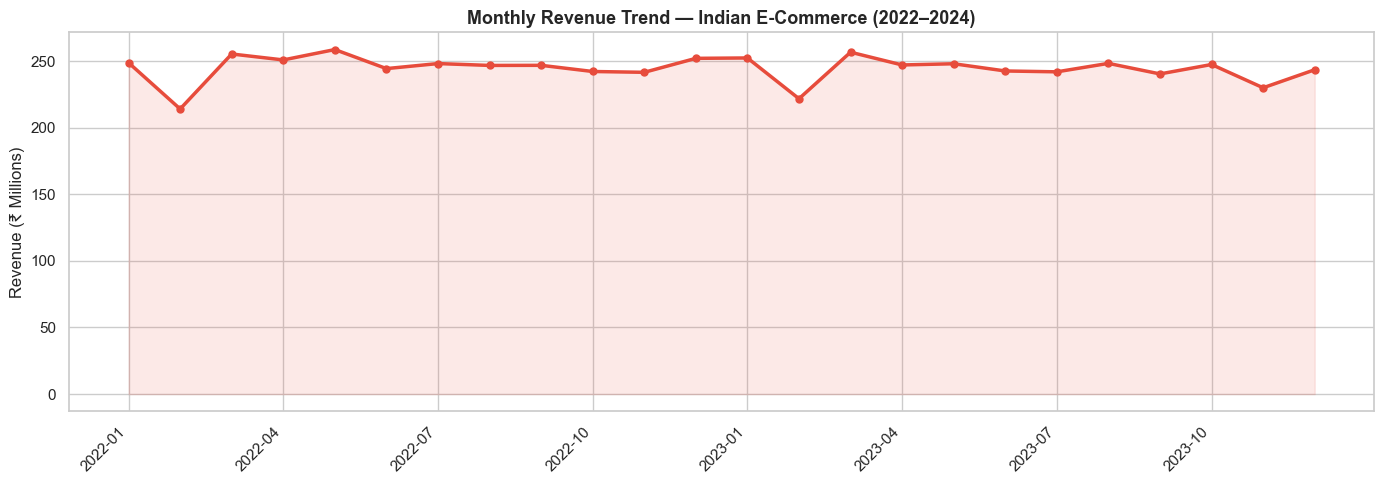

Peak Month: 2022-05


In [13]:
# Monthly revenue trend
pdf['year_month'] = pdf['order_date'].dt.to_period('M')
monthly = pdf.groupby('year_month')['total_amount_inr'].sum().reset_index()
monthly['year_month'] = monthly['year_month'].astype(str)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(range(len(monthly)), monthly['total_amount_inr'] / 1e6,
        color='#E74C3C', linewidth=2.5, marker='o', markersize=5)
ax.fill_between(range(len(monthly)), monthly['total_amount_inr'] / 1e6,
                alpha=0.12, color='#E74C3C')
step = max(1, len(monthly) // 8)
ax.set_xticks(range(0, len(monthly), step))
ax.set_xticklabels(monthly['year_month'].iloc[::step], rotation=45, ha='right')
ax.set_ylabel('Revenue (₹ Millions)')
ax.set_title('Monthly Revenue Trend — Indian E-Commerce (2022–2024)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print(f'Peak Month: {monthly.loc[monthly["total_amount_inr"].idxmax(), "year_month"]}')

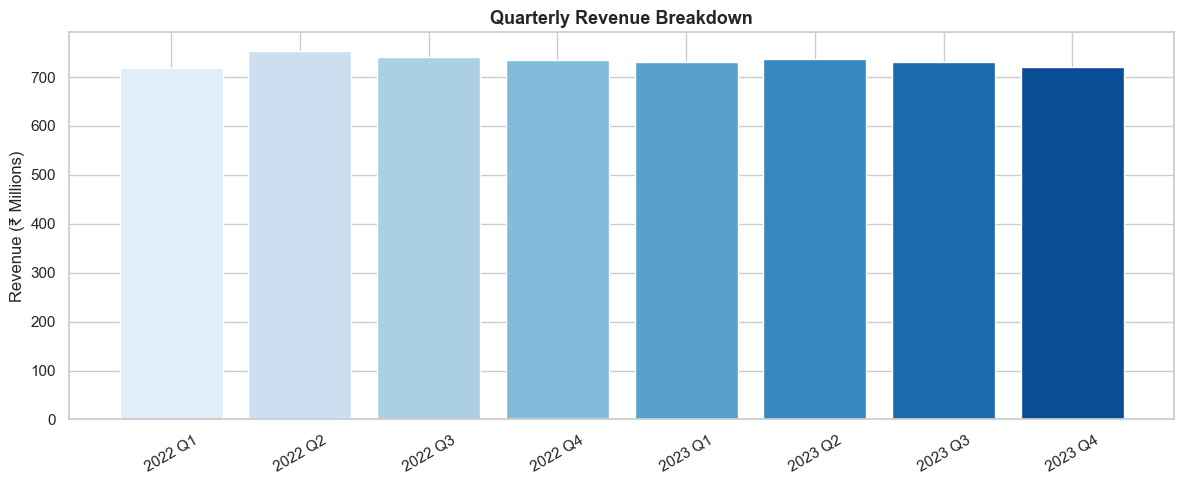

In [14]:
# Revenue by quarter
qtr = pdf.groupby(['order_year','order_quarter'])['total_amount_inr'].sum().reset_index()
qtr['label'] = qtr['order_year'].astype(str) + ' ' + qtr['order_quarter']

fig, ax = plt.subplots(figsize=(12, 5))
colors = sns.color_palette('Blues', len(qtr))
bars = ax.bar(qtr['label'], qtr['total_amount_inr'] / 1e6, color=colors, edgecolor='white')
ax.set_ylabel('Revenue (₹ Millions)')
ax.set_title('Quarterly Revenue Breakdown', fontsize=13, fontweight='bold')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

In [15]:
# Order status breakdown
status_counts = pdf['order_status'].value_counts()
print('Order Status Distribution:')
for s, c in status_counts.items():
    print(f'  {s:15s}: {c:,} ({c/len(pdf)*100:.1f}%)')

Order Status Distribution:
  Delivered      : 30,137 (60.3%)
  Shipped        : 7,506 (15.0%)
  Processing     : 4,911 (9.8%)
  Cancelled      : 3,919 (7.8%)
  Returned       : 2,569 (5.1%)
  Refunded       : 958 (1.9%)


---
## Section 6 — Category & Product Analysis

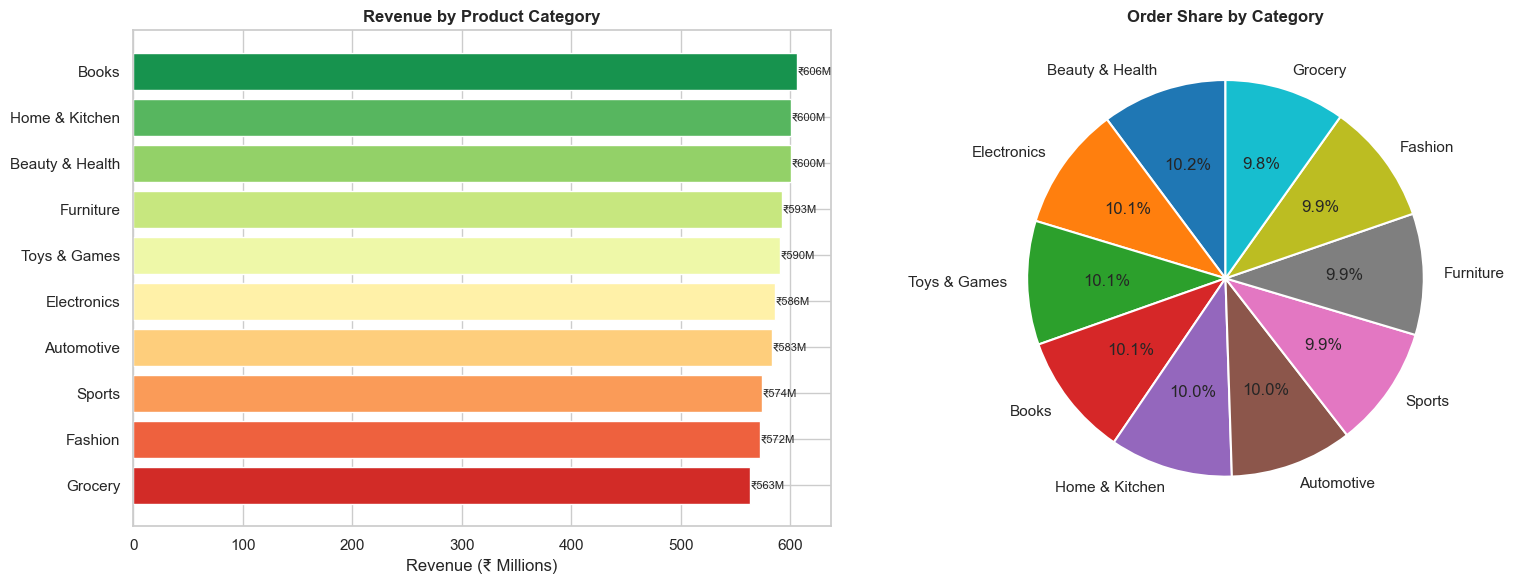

In [16]:
# Revenue by category
cat_rev = pdf.groupby('category')['total_amount_inr'].sum().sort_values(ascending=False).reset_index()
cat_rev.columns = ['Category', 'Revenue (₹)']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
bars = axes[0].barh(cat_rev['Category'], cat_rev['Revenue (₹)'] / 1e6,
                    color=sns.color_palette('RdYlGn_r', len(cat_rev)))
axes[0].invert_yaxis()
axes[0].set_xlabel('Revenue (₹ Millions)')
axes[0].set_title('Revenue by Product Category', fontweight='bold')
for bar, val in zip(bars, cat_rev['Revenue (₹)']):
    axes[0].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                 f'₹{val/1e6:.0f}M', va='center', fontsize=8)

# Pie chart — order count
cat_orders = pdf['category'].value_counts()
axes[1].pie(cat_orders.values, labels=cat_orders.index,
            autopct='%1.1f%%', startangle=90,
            colors=sns.color_palette('tab10', len(cat_orders)),
            wedgeprops=dict(edgecolor='white', linewidth=1.5))
axes[1].set_title('Order Share by Category', fontweight='bold')

plt.tight_layout()
plt.show()

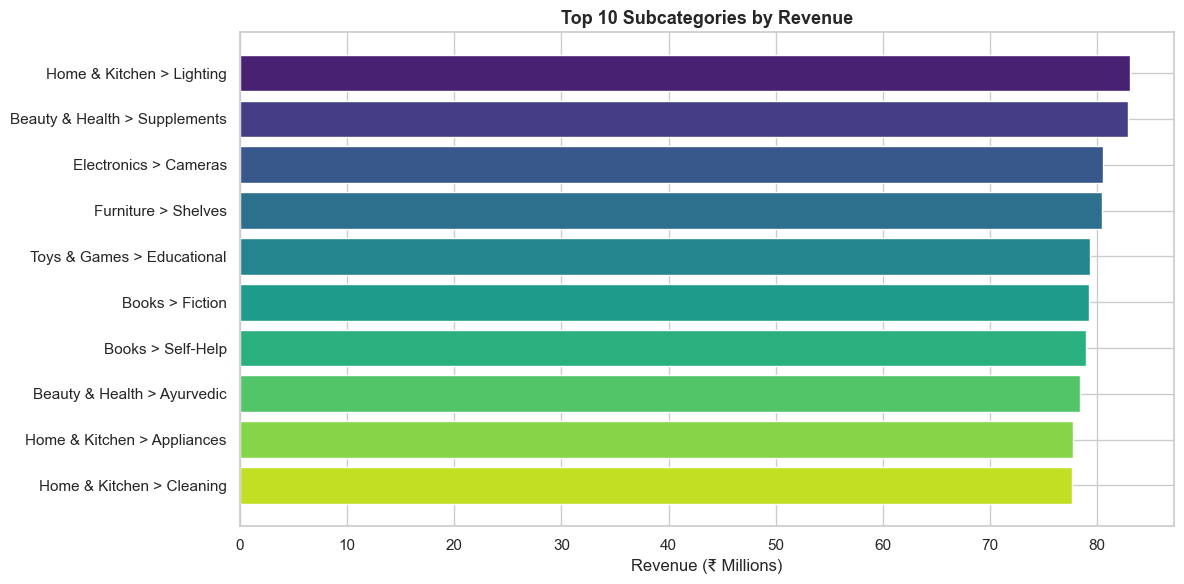

In [17]:
# Top 10 subcategories by revenue
subcat_rev = (pdf.groupby(['category','subcategory'])['total_amount_inr']
               .sum().reset_index()
               .sort_values('total_amount_inr', ascending=False)
               .head(10))
subcat_rev['label'] = subcat_rev['category'] + ' > ' + subcat_rev['subcategory']

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(subcat_rev['label'], subcat_rev['total_amount_inr'] / 1e6,
        color=sns.color_palette('viridis', 10))
ax.invert_yaxis()
ax.set_xlabel('Revenue (₹ Millions)')
ax.set_title('Top 10 Subcategories by Revenue', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [18]:
# Discount analysis by category
cat_disc = pdf.groupby('category')['discount_percent'].mean().sort_values(ascending=False)
print('Average Discount % by Category:')
for cat, disc in cat_disc.items():
    print(f'  {cat:20s}: {disc:.1f}%')

Average Discount % by Category:
  Fashion             : 25.3%
  Furniture           : 25.2%
  Sports              : 25.1%
  Books               : 25.0%
  Grocery             : 24.9%
  Electronics         : 24.9%
  Toys & Games        : 24.9%
  Automotive          : 24.9%
  Beauty & Health     : 24.8%
  Home & Kitchen      : 24.7%


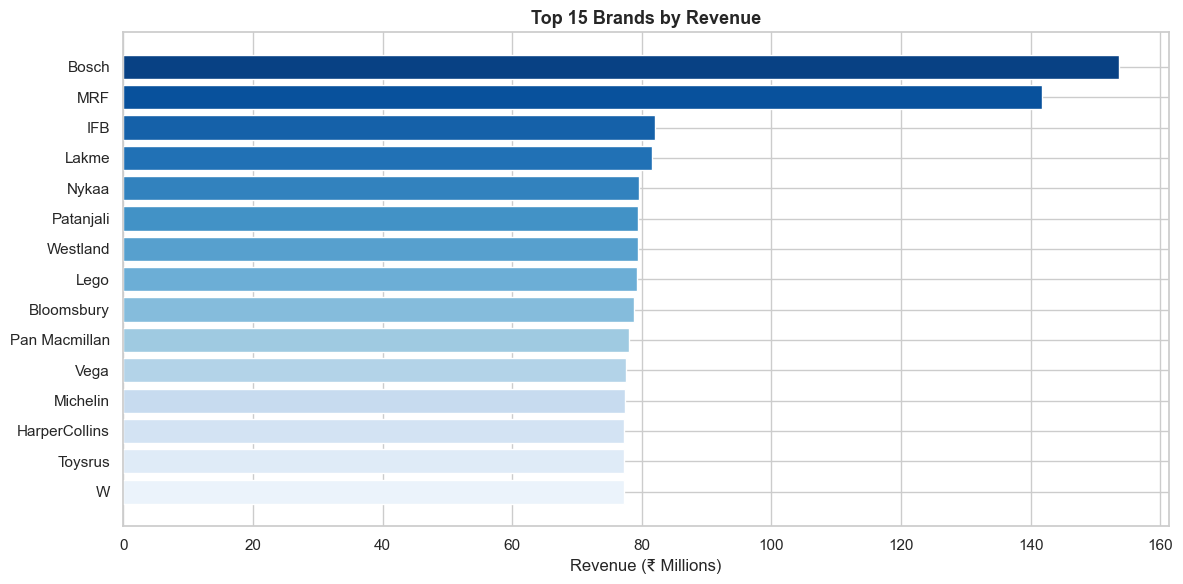

In [19]:
# Top brands by revenue
brand_rev = (pdf.groupby('brand')['total_amount_inr']
              .sum().sort_values(ascending=False).head(15).reset_index())

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(brand_rev['brand'], brand_rev['total_amount_inr'] / 1e6,
        color=sns.color_palette('Blues_r', 15))
ax.invert_yaxis()
ax.set_xlabel('Revenue (₹ Millions)')
ax.set_title('Top 15 Brands by Revenue', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section 7 — Customer & Demographic Analysis

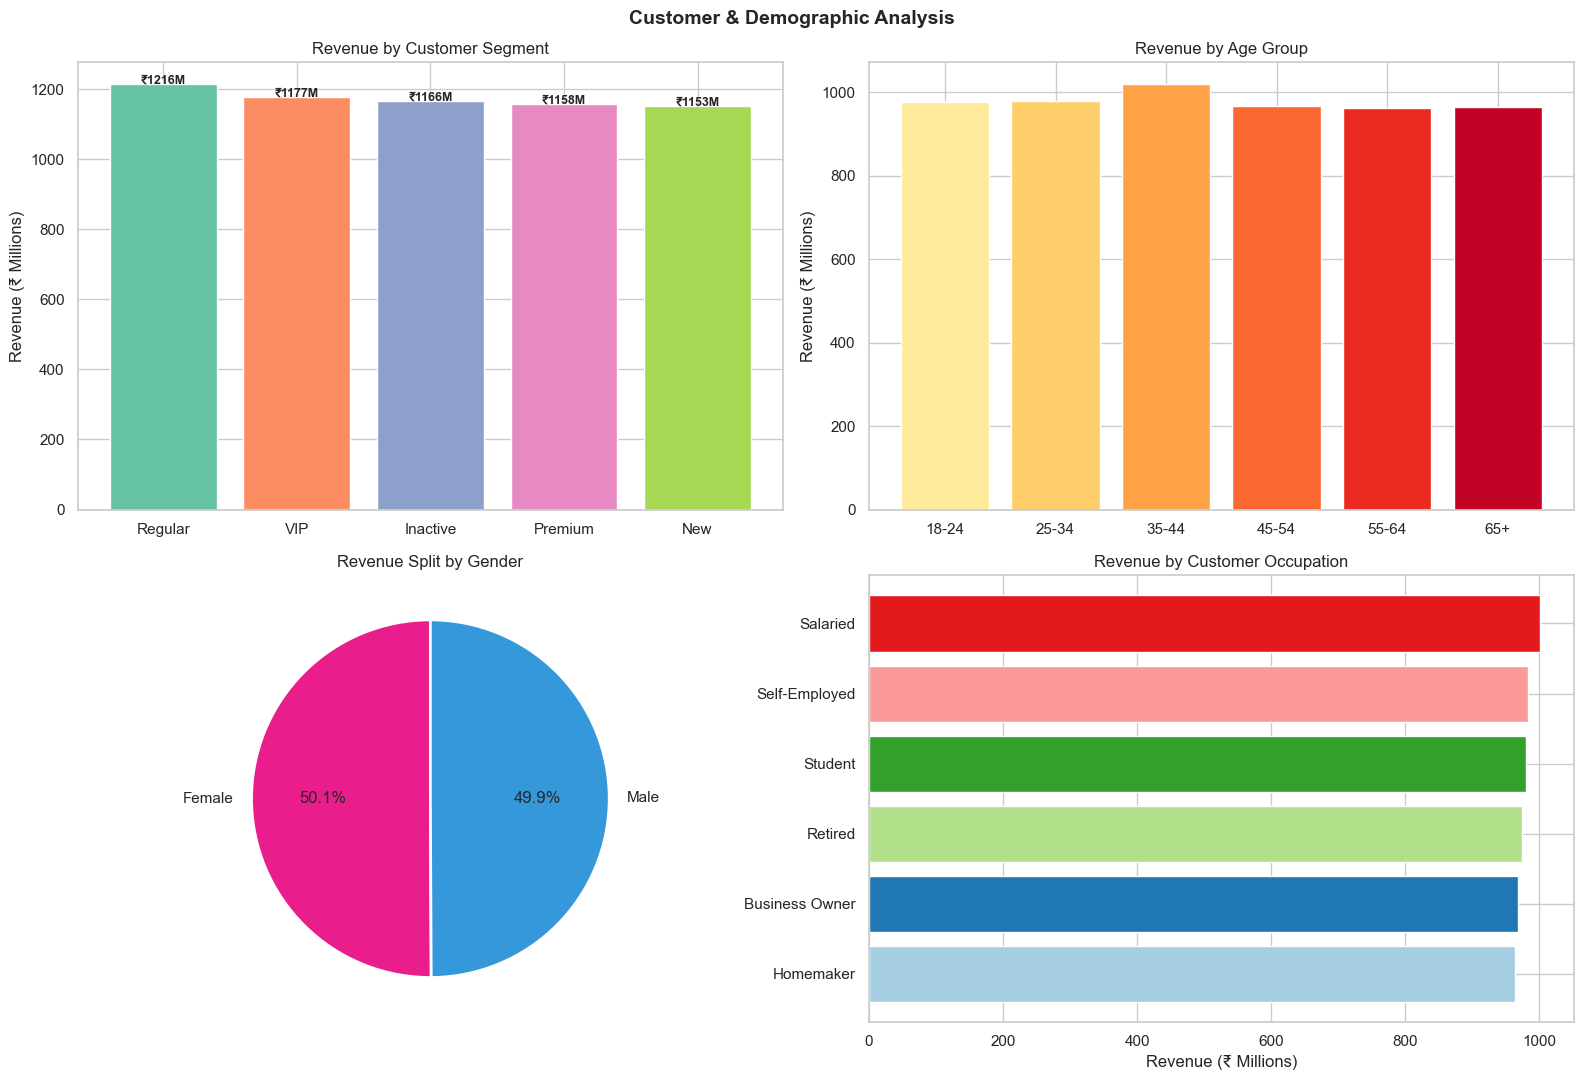

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Customer & Demographic Analysis', fontsize=14, fontweight='bold')

# 1. Revenue by customer segment
seg_rev = pdf.groupby('customer_segment')['total_amount_inr'].sum().sort_values(ascending=False)
axes[0,0].bar(seg_rev.index, seg_rev.values / 1e6,
               color=sns.color_palette('Set2', len(seg_rev)), edgecolor='white')
axes[0,0].set_ylabel('Revenue (₹ Millions)')
axes[0,0].set_title('Revenue by Customer Segment')
for i, v in enumerate(seg_rev.values):
    axes[0,0].text(i, v/1e6 + 0.5, f'₹{v/1e6:.0f}M', ha='center', fontsize=9, fontweight='bold')

# 2. Revenue by age group
age_rev = pdf.groupby('customer_age_group')['total_amount_inr'].sum()
order_age = ['18-24','25-34','35-44','45-54','55-64','65+']
age_rev = age_rev.reindex([x for x in order_age if x in age_rev.index])
axes[0,1].bar(age_rev.index, age_rev.values / 1e6,
               color=sns.color_palette('YlOrRd', len(age_rev)), edgecolor='white')
axes[0,1].set_ylabel('Revenue (₹ Millions)')
axes[0,1].set_title('Revenue by Age Group')

# 3. Gender split
gender_rev = pdf.groupby('customer_gender')['total_amount_inr'].sum()
axes[1,0].pie(gender_rev.values, labels=['Female','Male'],
               autopct='%1.1f%%', colors=['#E91E8C','#3498DB'],
               wedgeprops=dict(edgecolor='white', linewidth=2), startangle=90)
axes[1,0].set_title('Revenue Split by Gender')

# 4. Revenue by occupation
occ_rev = pdf.groupby('customer_occupation')['total_amount_inr'].sum().sort_values(ascending=True)
axes[1,1].barh(occ_rev.index, occ_rev.values / 1e6,
                color=sns.color_palette('Paired', len(occ_rev)))
axes[1,1].set_xlabel('Revenue (₹ Millions)')
axes[1,1].set_title('Revenue by Customer Occupation')

plt.tight_layout()
plt.show()

In [21]:
# Top customers by spend
top_customers = (pdf.groupby('customer_id')['total_amount_inr']
                  .sum().sort_values(ascending=False).head(10).reset_index())
top_customers.columns = ['Customer ID', 'Total Spend (₹)']
print('Top 10 Customers by Total Spend:')
print(top_customers.to_string(index=False))

Top 10 Customers by Total Spend:
Customer ID  Total Spend (₹)
  CUST48627       1199776.72
  CUST32930       1151005.62
  CUST45326       1047147.13
  CUST78606       1037418.35
  CUST52009       1026760.18
  CUST23362       1013481.67
  CUST76272        990622.58
  CUST71821        951152.12
  CUST58185        938392.72
  CUST24313        929036.65


---
## Section 8 — Platform & Payment Analysis

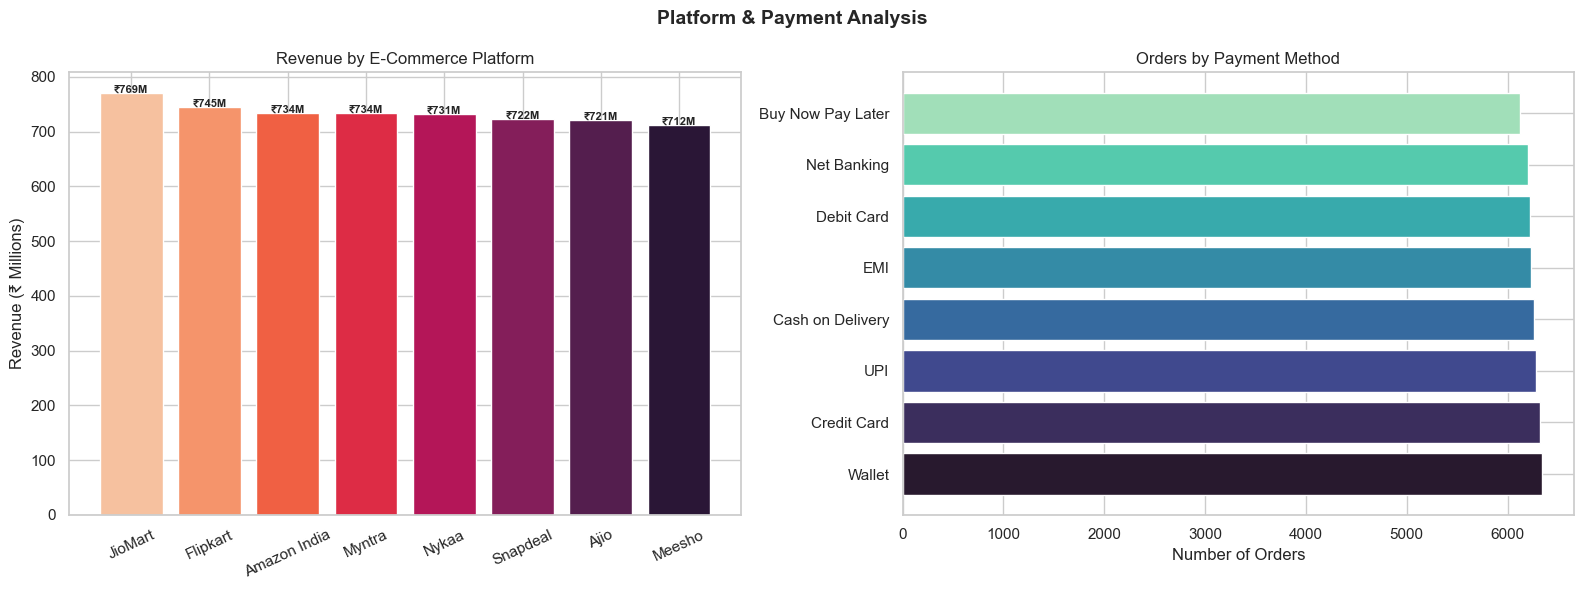

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Platform & Payment Analysis', fontsize=14, fontweight='bold')

# Platform revenue
plat_rev = pdf.groupby('platform')['total_amount_inr'].sum().sort_values(ascending=False)
axes[0].bar(plat_rev.index, plat_rev.values / 1e6,
             color=sns.color_palette('rocket_r', len(plat_rev)), edgecolor='white')
axes[0].set_ylabel('Revenue (₹ Millions)')
axes[0].set_title('Revenue by E-Commerce Platform')
axes[0].tick_params(axis='x', rotation=25)
for i, v in enumerate(plat_rev.values):
    axes[0].text(i, v/1e6 + 0.3, f'₹{v/1e6:.0f}M', ha='center', fontsize=8, fontweight='bold')

# Payment method
pay_counts = pdf['payment_method'].value_counts()
axes[1].barh(pay_counts.index, pay_counts.values,
              color=sns.color_palette('mako', len(pay_counts)))
axes[1].set_xlabel('Number of Orders')
axes[1].set_title('Orders by Payment Method')

plt.tight_layout()
plt.show()

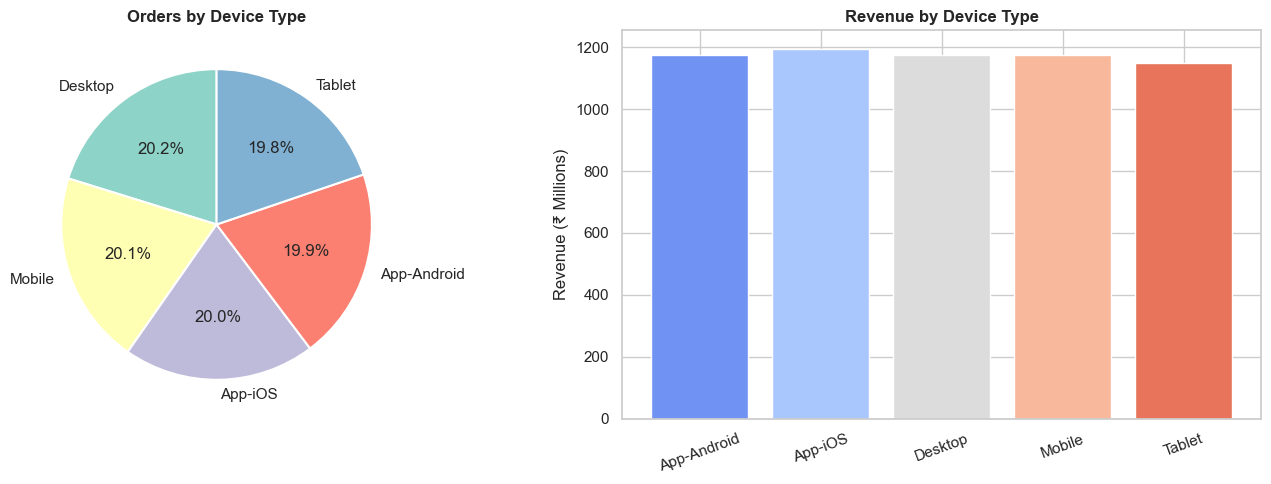

In [23]:
# Device type analysis
device_orders = pdf['device_type'].value_counts()
device_rev    = pdf.groupby('device_type')['total_amount_inr'].sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].pie(device_orders.values, labels=device_orders.index,
             autopct='%1.1f%%', colors=sns.color_palette('Set3', len(device_orders)),
             wedgeprops=dict(edgecolor='white', linewidth=1.5), startangle=90)
axes[0].set_title('Orders by Device Type', fontweight='bold')

axes[1].bar(device_rev.index, device_rev.values / 1e6,
             color=sns.color_palette('coolwarm', len(device_rev)), edgecolor='white')
axes[1].set_ylabel('Revenue (₹ Millions)')
axes[1].set_title('Revenue by Device Type', fontweight='bold')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

In [24]:
# Traffic source analysis
traffic = pdf.groupby('traffic_source')['total_amount_inr'].sum().sort_values(ascending=False)
print('Revenue by Traffic Source:')
for src, rev in traffic.items():
    print(f'  {src:20s}: ₹{rev:,.0f}')

Revenue by Traffic Source:
  Direct              : ₹847,626,982
  Paid Ad             : ₹843,989,550
  Referral            : ₹842,816,150
  Social Media        : ₹837,168,317
  Organic Search      : ₹836,082,781
  Email               : ₹834,069,229
  Influencer          : ₹826,902,646


---
## Section 9 — Regional Analysis

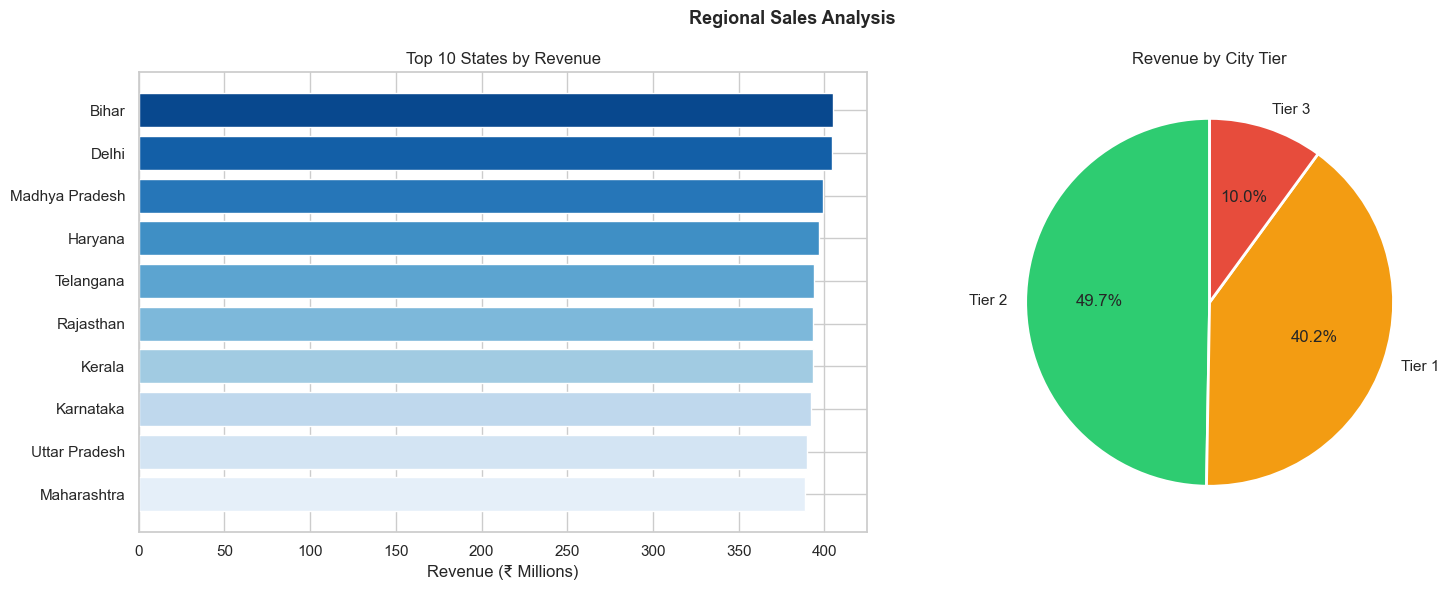

In [25]:
# Top states by revenue
state_rev = (pdf.groupby('state')['total_amount_inr']
              .sum().sort_values(ascending=False).head(10).reset_index())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Regional Sales Analysis', fontsize=13, fontweight='bold')

axes[0].barh(state_rev['state'], state_rev['total_amount_inr'] / 1e6,
              color=sns.color_palette('Blues_r', 10))
axes[0].invert_yaxis()
axes[0].set_xlabel('Revenue (₹ Millions)')
axes[0].set_title('Top 10 States by Revenue')

# City tier revenue
tier_rev = pdf.groupby('tier')['total_amount_inr'].sum().sort_values(ascending=False)
axes[1].pie(tier_rev.values, labels=tier_rev.index,
             autopct='%1.1f%%', colors=['#2ECC71','#F39C12','#E74C3C'],
             wedgeprops=dict(edgecolor='white', linewidth=2), startangle=90)
axes[1].set_title('Revenue by City Tier')

plt.tight_layout()
plt.show()

In [26]:
# Top cities
city_rev = (pdf.groupby('city')['total_amount_inr']
             .sum().sort_values(ascending=False).head(10).reset_index())
city_rev.columns = ['City', 'Revenue (₹)']
print('Top 10 Cities by Revenue:')
print(city_rev.to_string(index=False))

Top 10 Cities by Revenue:
      City   Revenue (₹)
      Pune  307972934.67
   Kolkata  307432593.61
     Patna  301942695.05
     Noida  299800866.66
    Jaipur  299335897.61
 Hyderabad  299189500.85
Chandigarh  299007860.41
 Bangalore   298076344.8
  Gurugram  297169193.61
     Surat   295242226.0


---
## Section 10 — Returns & Refund Analysis

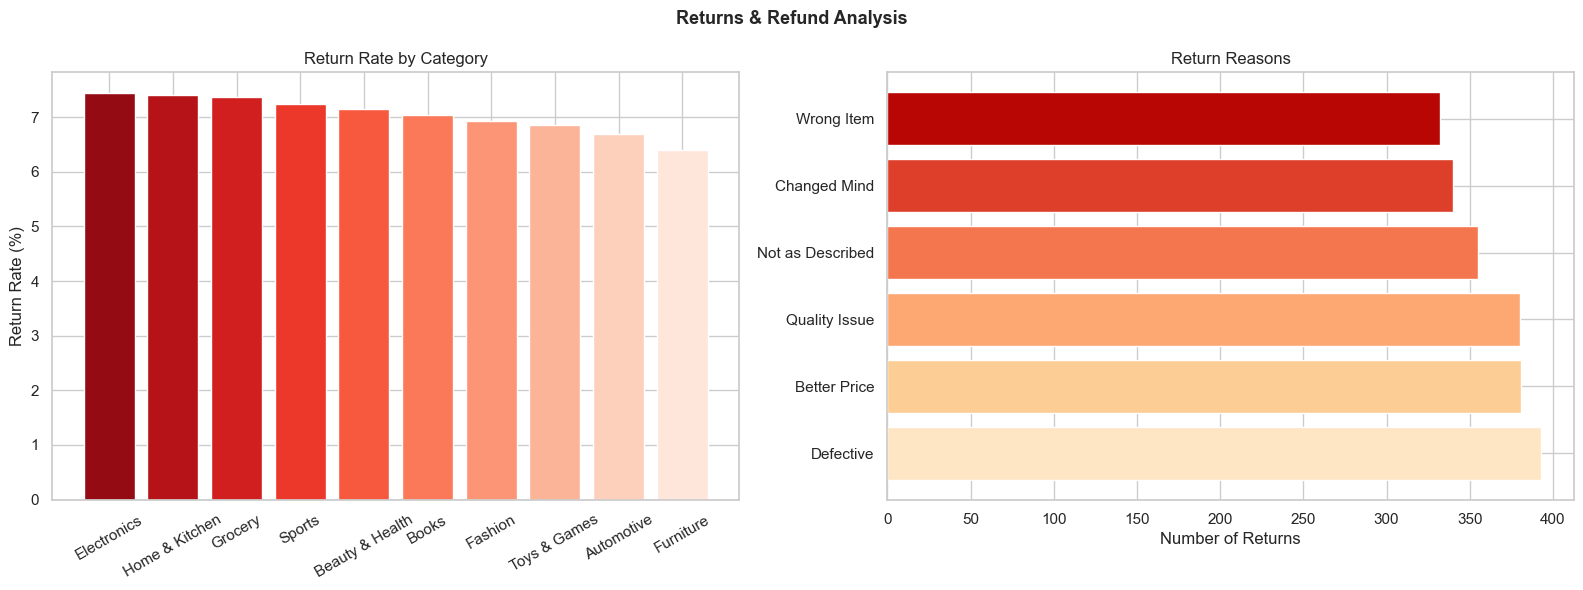

In [27]:
# Return rate by category
ret_by_cat = pdf.groupby('category')['return_flag'].mean().sort_values(ascending=False) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Returns & Refund Analysis', fontsize=13, fontweight='bold')

axes[0].bar(ret_by_cat.index, ret_by_cat.values,
             color=sns.color_palette('Reds_r', len(ret_by_cat)), edgecolor='white')
axes[0].set_ylabel('Return Rate (%)')
axes[0].set_title('Return Rate by Category')
axes[0].tick_params(axis='x', rotation=30)

# Return reasons
ret_reasons = pdf[pdf['return_flag'] == 1]['return_reason'].value_counts()
ret_reasons = ret_reasons[ret_reasons.index != '']
axes[1].barh(ret_reasons.index, ret_reasons.values,
              color=sns.color_palette('OrRd', len(ret_reasons)))
axes[1].set_xlabel('Number of Returns')
axes[1].set_title('Return Reasons')

plt.tight_layout()
plt.show()

In [28]:
# Shipping analysis
ship_rev = pdf.groupby('shipping_method').agg(
    Orders=('order_id','count'),
    Avg_Delivery=('delivery_days','mean'),
    Avg_Ship_Cost=('shipping_cost_inr','mean')
).reset_index().round(2)
print('Shipping Method Analysis:')
print(ship_rev.to_string(index=False))

Shipping Method Analysis:
shipping_method  Orders  Avg_Delivery  Avg_Ship_Cost
        Express   10125          5.49          39.01
  Free Shipping   10014          5.52          40.27
      Overnight    9807          5.46          38.65
       Same Day   10054          5.49          38.25
       Standard   10000           5.5          39.62


---
## Section 11 — Correlation & Advanced Analysis

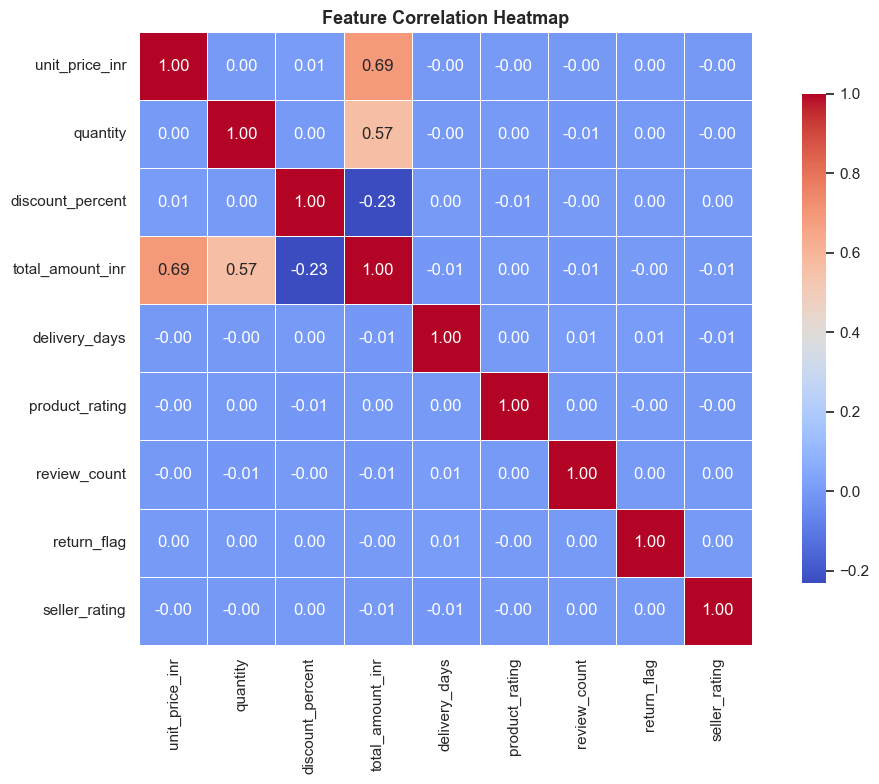

In [29]:
# Correlation heatmap
corr_cols = ['unit_price_inr','quantity','discount_percent','total_amount_inr',
             'delivery_days','product_rating','review_count','return_flag','seller_rating']
corr = pdf[corr_cols].corr()

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            ax=ax, linewidths=0.5, square=True, cbar_kws={'shrink':0.8})
ax.set_title('Feature Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [30]:
# GST collection by category
gst_by_cat = pdf.groupby('category')['gst_amount_inr'].sum().sort_values(ascending=False)
print('Total GST Collected by Category:')
for cat, gst in gst_by_cat.items():
    print(f'  {cat:20s}: ₹{gst:,.0f}')
print(f'\n  Total GST Collected : ₹{gst_by_cat.sum():,.0f}')

Total GST Collected by Category:
  Books               : ₹83,497,244
  Beauty & Health     : ₹82,727,106
  Home & Kitchen      : ₹81,975,974
  Furniture           : ₹80,598,294
  Automotive          : ₹79,694,371
  Toys & Games        : ₹79,456,639
  Fashion             : ₹79,364,179
  Electronics         : ₹78,938,571
  Sports              : ₹78,363,910
  Grocery             : ₹74,906,225

  Total GST Collected : ₹799,522,513


In [31]:
# Wishlist vs purchase analysis
wishlist_rate = pdf['wishlist_flag'].mean() * 100
wishlist_rev  = pdf[pdf['wishlist_flag']==1]['total_amount_inr'].mean()
normal_rev    = pdf[pdf['wishlist_flag']==0]['total_amount_inr'].mean()
print(f'Wishlist Rate          : {wishlist_rate:.1f}% of orders came from wishlist')
print(f'Avg Order (Wishlist)   : ₹{wishlist_rev:,.2f}')
print(f'Avg Order (Non-Wish.)  : ₹{normal_rev:,.2f}')

Wishlist Rate          : 49.8% of orders came from wishlist
Avg Order (Wishlist)   : ₹117,483.09
Avg Order (Non-Wish.)  : ₹117,263.82


---
## Section 12 — Why Dask? Scalability Demo

In [32]:
import time

# Dask groupby
t1 = time.time()
ddf2 = dd.read_csv('ecommerce_big_data.csv', dtype=str)
result_dask = ddf2['category'].value_counts().compute()
t2 = time.time()

# Pandas groupby
t3 = time.time()
result_pd = pdf['category'].value_counts()
t4 = time.time()

print('Scalability Comparison — value_counts() on 50,000 rows:')
print(f'  Dask (parallel)  : {t2-t1:.4f} sec')
print(f'  Pandas (single)  : {t4-t3:.4f} sec')
print()
print('Key Advantage of Dask:')
print('  For 10M+ rows, Dask processes partitions in parallel')
print('  while Pandas would crash due to RAM limitations.')
print(f'  Dask Partitions used: {ddf2.npartitions}')

Scalability Comparison — value_counts() on 50,000 rows:
  Dask (parallel)  : 0.7600 sec
  Pandas (single)  : 0.0039 sec

Key Advantage of Dask:
  For 10M+ rows, Dask processes partitions in parallel
  while Pandas would crash due to RAM limitations.
  Dask Partitions used: 1


---
## Section 13 — Final Insights Summary

In [33]:
top_cat    = pdf.groupby('category')['total_amount_inr'].sum().idxmax()
top_state  = pdf.groupby('state')['total_amount_inr'].sum().idxmax()
top_plat   = pdf.groupby('platform')['total_amount_inr'].sum().idxmax()
top_pay    = pdf['payment_method'].value_counts().idxmax()
top_seg    = pdf.groupby('customer_segment')['total_amount_inr'].sum().idxmax()
top_device = pdf['device_type'].value_counts().idxmax()
top_age    = pdf.groupby('customer_age_group')['total_amount_inr'].sum().idxmax()

print('=' * 65)
print('       📊 FINAL INSIGHTS — INDIAN E-COMMERCE BIG DATA')
print('=' * 65)
print(f'  1. Total Orders Processed (Dask) : {total_orders:,}')
print(f'  2. Total Revenue Generated       : ₹{total_revenue:,.0f}')
print(f'  3. Average Order Value           : ₹{avg_order_value:,.2f}')
print(f'  4. Top Revenue Category          : {top_cat}')
print(f'  5. Highest Revenue State         : {top_state}')
print(f'  6. Top E-Commerce Platform       : {top_plat}')
print(f'  7. Most Used Payment Method      : {top_pay}')
print(f'  8. Top Customer Segment          : {top_seg}')
print(f'  9. Top Device for Shopping       : {top_device}')
print(f' 10. Highest Spending Age Group    : {top_age}')
print(f' 11. Overall Return Rate           : {return_rate:.2f}%')
print(f' 12. Average Product Rating        : {avg_rating:.2f} / 5.0')
print(f' 13. Average Delivery Time         : {avg_delivery:.1f} days')
print(f' 14. Total Refunds Processed       : ₹{total_refunds:,.0f}')
print('=' * 65)
print()
print('  Dask Big Data Advantage:')
print('  • 50,000 rows processed in parallel partitions')
print('  • Same code scales to 50 million rows on a cluster')
print('  • Lazy evaluation — computes only when .compute() called')
print('=' * 65)
print('\n✅  Task 1 Complete!')

       📊 FINAL INSIGHTS — INDIAN E-COMMERCE BIG DATA
  1. Total Orders Processed (Dask) : 50,000
  2. Total Revenue Generated       : ₹5,868,655,654
  3. Average Order Value           : ₹117,373.11
  4. Top Revenue Category          : Books
  5. Highest Revenue State         : Bihar
  6. Top E-Commerce Platform       : JioMart
  7. Most Used Payment Method      : Wallet
  8. Top Customer Segment          : Regular
  9. Top Device for Shopping       : Desktop
 10. Highest Spending Age Group    : 35-44
 11. Overall Return Rate           : 7.05%
 12. Average Product Rating        : 3.75 / 5.0
 13. Average Delivery Time         : 5.5 days
 14. Total Refunds Processed       : ₹372,589,431

  Dask Big Data Advantage:
  • 50,000 rows processed in parallel partitions
  • Same code scales to 50 million rows on a cluster
  • Lazy evaluation — computes only when .compute() called

✅  Task 1 Complete!


---
*CODTECH IT Solutions Pvt. Ltd. — Data Analytics Internship — Task 1*